
# 1 Objective

You have historical monthly data of all milk products sold in the channel of price club stores at the national level.

You are supposed to be a data engineer and analyst in one of the 3 big manufacturers of milk products sold in this channel.

The objectives of your analysis are the following:

1. Provide understanding of the milk category **by manufacturer (fab)** in terms of a) **market share** composition by year, and b) **sales and price performance** over time. Identify the top fabs that make 80% of the market share for the last 12 months. Show relevant descriptive statistics according to your analysis and assumptions.

2. Provide initial correlation analysis to understand important relationship within the data. You have to justify how and why you did this correlation analysis. Explain your results

For 1) and 2) Present your analysis in tables and selected graphs to provide a **good understanding of the data.**

3. Design and run regression model(s) to estimate **price sensitivity (direct price elasticity)** for the top product of your manufacturer (fab#). Identify the top product as the product that sold the most for the last 12 months. For this model, only consider the price change as explanatory variable (do not include other factors such as seasonality or tren).

You have to present the regression output for the model and provide a **clear interpretation** for the regression output: parameter estimates (beta coefficients), t-Statistics, pvalues, 95% confidence intervals, and R-square.

4. Propose how you could **improve your model design to incorporate the following factors: cross-price elasticity with other products, seasonality and growth trend.** Here you have to explain your model design, not run the model.

5. For your model (of the top product), add variables to include the effects of seasonality and growing volume trend.

**Run the model, show the regression output and interpret the outputs**

In addition, respond to the following questions:

**Did the estimates of direct price elasticity change compared with the previous model?**
**What happened with the statistical significance of the price elasticity? Why do you think the estimates change, and which estimate is the best? Explain clearly with your own words.**

6. Propose how you could forecast price and sales of the top product for the next 24 months. Which types of models you can use to do this. You have to do your own research. Consider not only regression models, but any type of machine learning/ AI models.

# 2 PART 1 - Data wrangling and data understanding

You have to download (from Canvas) the following files:

1. DATOS_VENTAS.xlsx: historical monthly data for all products sold for the last 3-4 years

You have to:

1. Do a correct data wrangling/cleanning to prepare the data for descriptive statistics and modelling:

2. You have to check for null values, possible duplicate records (1 same product with 2 product ID, or 1 product ID with 2 different product names),

3. Then you have to do the right data collapsing, possible reshaping, and variable transformations, and come up with the right data structure for analysis. Remember dataset structure types (long-format, wide-format).

4. Do the corresponding data analysis to respond to the objective 1)

5. Run and interpret the regression model for your fab

# 3 PART 2 - Data modelling

You have to design, run models to respond to the objective and questions stated in 3), 4) and 5)

Go to Canvas and check DEADLINES for each part


In [126]:
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

## Cargar los datos del excel

In [127]:
df = pd.read_excel("./DATA_VENTAS.xlsx")
df

,CORTE,FABRICANTE,ID,PRODUCTO,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
0,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,14,4,2022-04-04,2022-04-01,17492.00,876,19.968037,73,239.616438,12
1,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,15,4,2022-04-11,2022-04-01,53364.90,2676,19.942040,223,239.304484,12
2,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,16,4,2022-04-18,2022-04-01,75747.96,3828,19.787868,319,237.454420,12
3,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,17,4,2022-04-25,2022-04-01,73193.36,3684,19.867904,307,238.414853,12
4,TN,FAB1,1L Sel Des Deslactosada,FAB1_1L Sel Des Deslactosada,2022,18,5,2022-05-02,2022-05-01,94031.14,4644,20.247877,387,242.974522,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3291,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,29,7,2025-07-14,2025-07-01,639315.95,27696,23.083332,2308,276.999978,12
3292,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,1533783.80,69432,22.090445,5786,265.085344,12
3293,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,547482.24,23940,22.868932,1995,274.427188,12
3294,TN,FAB3,1L Ent Entera,FAB3_1L Ent Entera,2025,31,7,2025-07-28,2025-07-01,2091665.53,96276,21.725721,8023,260.708654,12


## Limpiar los datos tirando las columnas que no brindan información importante

1. Corte: Mismo valor en todas las instancias. 
1. Producto: Calculado mediante la fábrica y ID del producto
1. FechaM: Calculados mediante la fecha desglozada: año, semana mes -> Consideré que es mejor tener los valores particulares e independientes
1. Unidades en Paquete: Todos los productos cuentan con paquetes de 12

In [128]:
# Drop unimportant columns
df_clean = df.drop(columns=["CORTE", "PRODUCTO"])
df_clean

,FABRICANTE,ID,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
0,FAB1,1L Sel Des Deslactosada,2022,14,4,2022-04-04,2022-04-01,17492.00,876,19.968037,73,239.616438,12
1,FAB1,1L Sel Des Deslactosada,2022,15,4,2022-04-11,2022-04-01,53364.90,2676,19.942040,223,239.304484,12
2,FAB1,1L Sel Des Deslactosada,2022,16,4,2022-04-18,2022-04-01,75747.96,3828,19.787868,319,237.454420,12
3,FAB1,1L Sel Des Deslactosada,2022,17,4,2022-04-25,2022-04-01,73193.36,3684,19.867904,307,238.414853,12
4,FAB1,1L Sel Des Deslactosada,2022,18,5,2022-05-02,2022-05-01,94031.14,4644,20.247877,387,242.974522,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3291,FAB3,1L Ent Entera,2025,29,7,2025-07-14,2025-07-01,639315.95,27696,23.083332,2308,276.999978,12
3292,FAB3,1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,1533783.80,69432,22.090445,5786,265.085344,12
3293,FAB3,1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,547482.24,23940,22.868932,1995,274.427188,12
3294,FAB3,1L Ent Entera,2025,31,7,2025-07-28,2025-07-01,2091665.53,96276,21.725721,8023,260.708654,12


## Limpiar dataset

Encontré 3 valores nulos en precio, los registros con 0 en cantidad de litros vendidos no me permiten calcular el precio de venta de los litros, y las ventas negativas representan que pudo haber devoluciones o algo por el estilo que no es de importancia en este análisis para determinar la demanda.

Por ello decidí eliminarlos del dataframe antes de continuar con el análisis.

Debido a las agrupaciones semanales lo ideal es calcular el promedio de precio unitario por litromediante la venta y litros vendidos.
Se considera repetidos si se tiene el mismo ID en la misma semaan y año, solución: Acumular las ventas, litros, paquetes y el promedio en precio unitario por litro y por paquete.

Esto fue ya que las ventas se acumulan, y los datos repetidos son por un cambio en el precio, el cual no hace sentido acumular.

In [129]:
# Group duplicate rows together for visual comparison
print("Nulos por columna:")
display(df_clean.isna().sum())

print("Filas con LITROS = 0:")
display(df_clean[df_clean["LITROS"] == 0])

print("Filas con VENTA_VALOR negativa:")
display(df_clean[df_clean["VENTA_VALOR"] < 0])

duplicates = df_clean[df_clean.duplicated(subset=["ID", "AÑO1", "SEMANA"], keep=False)]
display(duplicates)

df_merged = df_clean.groupby(["ID", "AÑO1", "SEMANA"], as_index=False).agg({
	"FABRICANTE": "first",
 	"MES": "first",
 	"FECHAM": "first",
  "VENTA_VALOR": "sum",
  "LITROS": "sum",
  "PAQUETES": "sum",
})

cols = ["FABRICANTE"] + [col for col in df_merged.columns if col != "FABRICANTE"]
df_merged = df_merged[cols]

df_merged["PRECIO_UNITARIO_LITRO"] = df_merged["VENTA_VALOR"] / df_merged["LITROS"]
df_merged["PRECIO_UNITARIO_PAQUETE"] = df_merged["VENTA_VALOR"] / df_merged["PAQUETES"]

print("Limpio:")
display(df_merged)

Nulos por columna:


FABRICANTE                 0
ID                         0
AÑO1                       0
SEMANA                     0
MES                        0
FECHAW                     0
FECHAM                     0
VENTA_VALOR                0
LITROS                     0
PRECIO_UNITARIO_LITRO      3
PAQUETES                   0
PRECIO_UNITARIO_PAQUETE    3
UNIDADES_EN_PAQUETE        0
dtype: int64

Filas con LITROS = 0:


,FABRICANTE,ID,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
1659,FAB2,Des Light Deslactosada Light 1L,2025,4,1,2025-01-20,2025-01-01,-268.0,0,NaN,0,NaN,12
3268,FAB3,1L Ent Entera,2025,17,4,2025-04-21,2025-04-01,0.0,0,NaN,0,NaN,12


Filas con VENTA_VALOR negativa:


,FABRICANTE,ID,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
1304,FAB1,Leche Clasica Semi 1 L,2023,36,9,2023-09-04,2023-09-01,-3378.01,-156,21.653910,-13,259.846923,12
1659,FAB2,Des Light Deslactosada Light 1L,2025,4,1,2025-01-20,2025-01-01,-268.00,0,NaN,0,NaN,12
1998,FAB2,Entera Entera 1 L,2023,52,12,2023-12-25,2023-12-01,-500.00,-24,20.833333,-2,250.000000,12
2491,FAB6,12/1L Leche Y Pan En Tera,2023,48,11,2023-11-27,2023-11-01,-1020.00,-60,17.000000,-5,204.000000,12
2868,FAB3,1L Desl Deslactosada,2024,17,4,2024-04-22,2024-04-01,-1057320.00,-46992,22.500000,-3916,270.000000,12
3179,FAB3,1L Ent Entera,2024,17,4,2024-04-22,2024-04-01,-489968.00,-21696,22.583333,-1808,271.000000,12


,FABRICANTE,ID,AÑO1,SEMANA,MES,FECHAW,FECHAM,VENTA_VALOR,LITROS,PRECIO_UNITARIO_LITRO,PAQUETES,PRECIO_UNITARIO_PAQUETE,UNIDADES_EN_PAQUETE
1629,FAB2,Des Light Deslactosada Light 1L,2024,41,10,2024-10-07,2024-10-01,211303.67,9336,22.633212,778,271.598548,12
1630,FAB2,Des Light Deslactosada Light 1L,2024,41,10,2024-10-07,2024-10-01,8397.00,396,21.204545,33,254.454545,12
1631,FAB2,Des Light Deslactosada Light 1L,2024,42,10,2024-10-14,2024-10-01,210346.78,10116,20.793474,843,249.521684,12
1632,FAB2,Des Light Deslactosada Light 1L,2024,42,10,2024-10-14,2024-10-01,80793.00,3924,20.589450,327,247.073394,12
1633,FAB2,Des Light Deslactosada Light 1L,2024,43,10,2024-10-21,2024-10-01,40552.91,1884,21.524899,157,258.298790,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3291,FAB3,1L Ent Entera,2025,29,7,2025-07-14,2025-07-01,639315.95,27696,23.083332,2308,276.999978,12
3292,FAB3,1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,1533783.80,69432,22.090445,5786,265.085344,12
3293,FAB3,1L Ent Entera,2025,30,7,2025-07-21,2025-07-01,547482.24,23940,22.868932,1995,274.427188,12
3294,FAB3,1L Ent Entera,2025,31,7,2025-07-28,2025-07-01,2091665.53,96276,21.725721,8023,260.708654,12


Limpio:


,FABRICANTE,ID,AÑO1,SEMANA,MES,FECHAM,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE
0,FAB2,100 70+30,2022,1,1,2022-01-01,271.00,12,1,22.583333,271.000000
1,FAB2,100 Low C Arb,2023,44,11,2023-11-01,24431.00,1092,91,22.372711,268.472527
2,FAB2,100 Low C Arb,2023,45,11,2023-11-01,83922.97,3744,312,22.415323,268.983878
3,FAB2,100 Low C Arb,2023,46,11,2023-11-01,77492.88,3456,288,22.422708,269.072500
4,FAB2,100 Low C Arb,2023,47,11,2023-11-01,131805.01,5904,492,22.324697,267.896362
...,...,...,...,...,...,...,...,...,...,...,...
3013,FAB5,Mm Leche Deslac Ligh,2025,27,7,2025-07-01,629750.74,33060,2755,19.048722,228.584661
3014,FAB5,Mm Leche Deslac Ligh,2025,28,7,2025-07-01,536578.27,28188,2349,19.035699,228.428382
3015,FAB5,Mm Leche Deslac Ligh,2025,29,7,2025-07-01,548231.53,28548,2379,19.203851,230.446208
3016,FAB5,Mm Leche Deslac Ligh,2025,30,7,2025-07-01,548597.09,28692,2391,19.120211,229.442530


In [130]:
df_merged_monthly = df_merged.groupby(["ID", "FECHAM"], as_index=False).agg({
	"FABRICANTE": "first",
 	"AÑO1": "first",
 	"MES": "first",
  "VENTA_VALOR": "sum",
  "LITROS": "sum",
  "PAQUETES": "sum",
})
cols = ["FABRICANTE"] + [col for col in df_merged_monthly.columns if col != "FABRICANTE"]
df_merged_monthly = df_merged_monthly[cols]

df_merged_monthly["PRECIO_UNITARIO_LITRO"] = df_merged_monthly["VENTA_VALOR"] / df_merged_monthly["LITROS"]
df_merged_monthly["PRECIO_UNITARIO_PAQUETE"] = df_merged_monthly["VENTA_VALOR"] / df_merged_monthly["PAQUETES"]

print("Limpio:")
display(df_merged_monthly)

Limpio:


,FABRICANTE,ID,FECHAM,AÑO1,MES,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE
0,FAB2,100 70+30,2022-01-01,2022,1,271.00,12,1,22.583333,271.000000
1,FAB2,100 Low C Arb,2023-11-01,2023,11,402512.89,17988,1499,22.376745,268.520941
2,FAB2,100 Low C Arb,2023-12-01,2023,12,623084.68,29664,2472,21.004742,252.056909
3,FAB2,100 Low C Arb,2024-01-01,2024,1,679620.91,30300,2525,22.429733,269.156796
4,FAB2,100 Low C Arb,2024-02-01,2024,2,845147.81,38076,3173,22.196339,266.356070
...,...,...,...,...,...,...,...,...,...,...
705,FAB5,Mm 12/1L Leche Ente Members Mark,2025-06-01,2025,6,6780388.34,334920,27910,20.244800,242.937597
706,FAB5,Mm 12/1L Leche Ente Members Mark,2025-07-01,2025,7,9206183.92,476208,39684,19.332275,231.987298
707,FAB5,Mm Leche Deslac Ligh,2025-05-01,2025,5,1264602.61,64824,5402,19.508247,234.098965
708,FAB5,Mm Leche Deslac Ligh,2025-06-01,2025,6,1880243.64,93720,7810,20.062352,240.748225


In [131]:
# Auditoría de conservación: el colapso debe preservar ventas, litros y paquetes.
raw_totals = df_clean[["VENTA_VALOR", "LITROS", "PAQUETES"]].sum()
weekly_totals = df_merged[["VENTA_VALOR", "LITROS", "PAQUETES"]].sum()
monthly_totals = df_merged_monthly[["VENTA_VALOR", "LITROS", "PAQUETES"]].sum()
conservation_check = pd.DataFrame({
    "original_filtrado": raw_totals,
    "semanal": weekly_totals,
    "mensual": monthly_totals,
    "diferencia_original_mensual": raw_totals - monthly_totals,
})
display(conservation_check)

,original_filtrado,semanal,mensual,diferencia_original_mensual
VENTA_VALOR,2.292962e+09,2.292962e+09,2.292962e+09,0.0
LITROS,1.135411e+08,1.135411e+08,1.135411e+08,0.0
PAQUETES,9.460394e+06,9.460394e+06,9.460394e+06,0.0


In [132]:
def see_nan_values(df):
	df.info()
	nan_values = df.isnull().sum()
	print(nan_values / len(df) * 100)

	print(f"Lenght of dataset: {len(df)}")

In [133]:
see_nan_values(df_merged_monthly)

<class 'pandas.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   FABRICANTE               710 non-null    str           
 1   ID                       710 non-null    str           
 2   FECHAM                   710 non-null    datetime64[us]
 3   AÑO1                     710 non-null    int64         
 4   MES                      710 non-null    int64         
 5   VENTA_VALOR              710 non-null    float64       
 6   LITROS                   710 non-null    int64         
 7   PAQUETES                 710 non-null    int64         
 8   PRECIO_UNITARIO_LITRO    710 non-null    float64       
 9   PRECIO_UNITARIO_PAQUETE  710 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(4), str(2)
memory usage: 55.6 KB
FABRICANTE                 0.0
ID                         0.0
FECHAM                     0.0
AÑO

In [134]:
missing_prices = df_merged_monthly[
    df_merged_monthly["PRECIO_UNITARIO_LITRO"].isna() |
    df_merged_monthly["PRECIO_UNITARIO_PAQUETE"].isna()
]

display(missing_prices)

# df_clean = df_merged_monthly.dropna()
# see_nan_values(df_clean)

,FABRICANTE,ID,FECHAM,AÑO1,MES,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE


In [135]:
df = df_merged.sort_values(
	by=["FECHAM"]
).reset_index(drop=True)

display(df)

,FABRICANTE,ID,AÑO1,SEMANA,MES,FECHAM,VENTA_VALOR,LITROS,PAQUETES,PRECIO_UNITARIO_LITRO,PRECIO_UNITARIO_PAQUETE
0,FAB2,100 70+30,2022,1,1,2022-01-01,271.00,12,1,22.583333,271.000000
1,FAB3,1L D Li Deslactosada Light,2022,3,1,2022-01-01,192478.00,9684,807,19.875878,238.510533
2,FAB3,1L D Li Deslactosada Light,2022,2,1,2022-01-01,291894.90,16296,1358,17.912058,214.944698
3,FAB3,1L D Li Deslactosada Light,2022,1,1,2022-01-01,331087.04,18480,1540,17.915965,214.991584
4,FAB1,Leche Clasica Light 1 L,2022,4,1,2022-01-01,283534.96,14544,1212,19.494978,233.939736
...,...,...,...,...,...,...,...,...,...,...,...
3013,FAB3,1L Ent Entera,2025,28,7,2025-07-01,1271356.94,54072,4506,23.512297,282.147568
3014,FAB3,1L Ent Entera,2025,27,7,2025-07-01,1596434.21,67512,5626,23.646673,283.760080
3015,FAB1,Leche Clasica Deslactosada 1 L,2025,28,7,2025-07-01,1792644.94,83544,6962,21.457495,257.489937
3016,FAB2,12/1L 100 Proteina,2025,28,7,2025-07-01,543454.08,18888,1574,28.772452,345.269428


## Observación 1
El porcentaje de ventas en el mercado de la fábrica 2 en que estoy haciendo el estudio es del 19.62%, cayendo en el tercer lugar. Durante los años se puede ver que se mantiene alrededor de 20 excepto en el 2025, cuando solo llego a representar el 11% del mercado, su peor año.

Comparando el valor en el mercado y el volumen de ventas del mercado podemos entender un poco más la informacón. Mientras que ventas nos dice cuanto están ganando en el mercado lacteo, con volumen ya entendemos la cantidad que venden y por ende la relación entre ambas. La fábrica 2 tiene un menor porcentaje en las ganancias del mercado, pero en volumen aumenta, lo que nos dice que su precio de venta promedio es menor al de la competencia. 

En los últimos 12 meses se peude ver que la fábrica 2 solo representa un ~13% del mercado, y el top 80% está repartido entre:
1. FAB1 - 36%
1. FAB3 - 28%
1. FAB5 - 22%

Estos tres fabricantes concentran aproximadamente el 86.6% en los últimos 12 meses. 

,VENTA_VALOR,MARKET_SHARE
FABRICANTE,,
FAB1,9.660932e+08,42.132989
FAB2,4.497629e+08,19.614934
FAB3,6.913222e+08,30.149751
FAB5,1.563710e+08,6.819607
FAB6,2.941226e+07,1.282719


,FABRICANTE,LITROS,VOLUME_SHARE
0,FAB1,47584872,41.909827
1,FAB2,23032956,20.286010
2,FAB3,32931156,29.003736
3,FAB5,8098860,7.132978
4,FAB6,1893240,1.667449


VENTA_VALOR  MARKET_SHARE
FABRICANTE AÑO1                            
FAB1       2022  2.634132e+08     44.636707
           2023  2.835142e+08     46.429626
           2024  2.745553e+08     41.387640
           2025  1.446106e+08     33.722316
FAB2       2022  1.240779e+08     21.025637
           2023  1.382942e+08     22.647710
           2024  1.375519e+08     20.735161
           2025  4.983890e+07     11.622129
FAB3       2022  1.853947e+08     31.416076
           2023  1.766527e+08     28.929480
           2024  2.092758e+08     31.547134
           2025  1.199990e+08     27.983042
FAB5       2024  4.199187e+07      6.330034
           2025  1.143791e+08     26.672513
FAB6       2022  1.724103e+07      2.921580
           2023  1.217102e+07      1.993184
           2024  2.040000e+02      0.000031

Text(0.5, 1.0, 'Market Share overview')

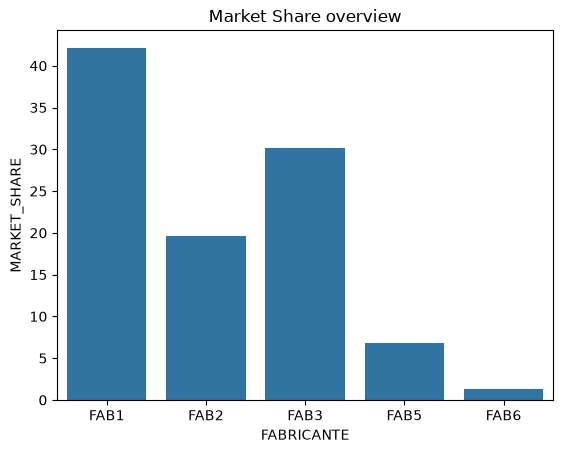

In [136]:
market_share = df_merged_monthly.groupby("FABRICANTE").agg({
	"VENTA_VALOR": "sum"
})
market_share_year = df_merged_monthly.groupby(["FABRICANTE", "AÑO1"]).agg({
	"VENTA_VALOR": "sum"
})

volume_share = (
    df_merged_monthly
    .groupby("FABRICANTE")["LITROS"]
    .sum()
    .reset_index()
)

volume_share["VOLUME_SHARE"] = (
    volume_share["LITROS"]
    / volume_share["LITROS"].sum()
    * 100
)


total = market_share["VENTA_VALOR"].sum()
total_anual = market_share_year.groupby("AÑO1")["VENTA_VALOR"].sum()

market_share["MARKET_SHARE"] = market_share["VENTA_VALOR"] / total * 100
market_share_year["MARKET_SHARE"] = market_share_year["VENTA_VALOR"] / total_anual * 100
display(market_share)
display(volume_share)
display(market_share_year)

sns.barplot(market_share, x="FABRICANTE", y="MARKET_SHARE")
plt.title("Market Share overview")

,VENTA_VALOR,SHARE
FABRICANTE,,
FAB1,2.553917e+08,35.932638
FAB2,9.488954e+07,13.350596
FAB3,2.040994e+08,28.716002
FAB5,1.563707e+08,22.000764


Text(0.5, 1.0, 'Market share in the last 12 months')

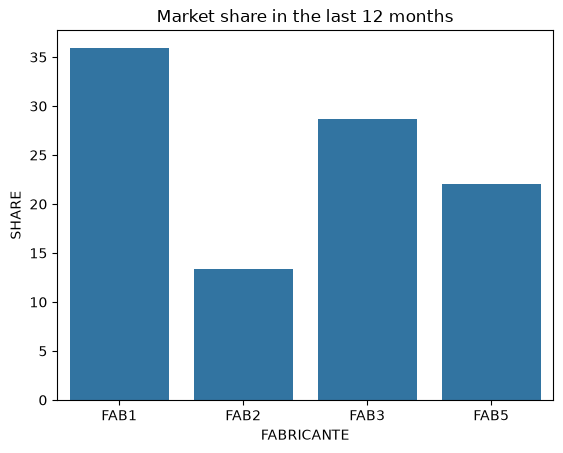

In [137]:
market_share_monthly = (
    df_merged_monthly.groupby(["FABRICANTE", "AÑO1", "MES"])["VENTA_VALOR"]
      .sum()
      .reset_index()
      .sort_values(["AÑO1", "MES"])
)

# Últimos 12 meses
last_12_months = market_share_monthly[
    ["AÑO1", "MES"]
].drop_duplicates().tail(12)

market_share_monthly = market_share_monthly.merge(
    last_12_months,
    on=["AÑO1", "MES"],
    how="inner"
)

market_share_monthly = market_share_monthly.groupby("FABRICANTE").agg({
	"VENTA_VALOR": "sum"
})

market_share_monthly["SHARE"] = market_share_monthly["VENTA_VALOR"] / market_share_monthly["VENTA_VALOR"].sum() * 100
display(market_share_monthly)

sns.barplot(market_share_monthly, x="FABRICANTE", y="SHARE")
plt.title("Market share in the last 12 months")


## Filtrar Por fábrica 2

Como se puede observar en las gráficas, el precio de venta de la leche ah aumentado considerablemente los últimos años, pero las ventas de esta fábrica disminuyeron de manera drástica en el último trimestre de 2024. Justamente cuando la leche subió a costar por encima de 21 pesos por litro.

Mínimo litros: 12
Media litros: 111270.31884057971
Mediana litros: 87144.0
Máximo litros: 306444

Mínimo precio por litro: 12.283787037037039
Media precio por litro: 20.606028468194342
Mediana precio por litro: 19.677367047110238
Máximo precio por litro: 28.746252764612947


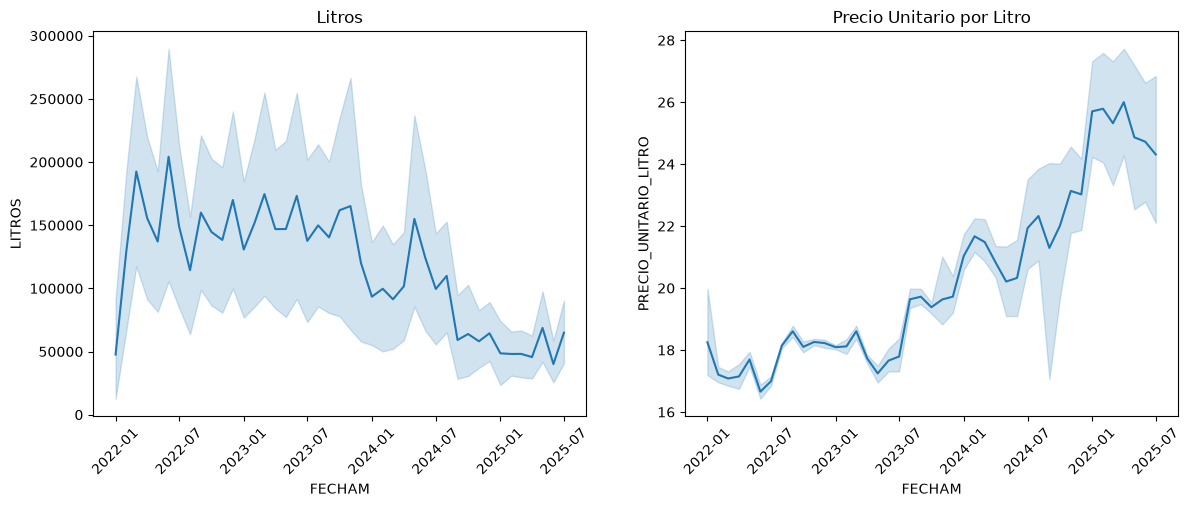

In [138]:
df_fab2 = df_merged_monthly[df_merged_monthly["FABRICANTE"] == "FAB2"]
df_fab2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(df_fab2, x="FECHAM", y="LITROS", ax=axes[0])
axes[0].set_title("Litros")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(df_fab2, x="FECHAM", y="PRECIO_UNITARIO_LITRO", ax=axes[1])
axes[1].set_title("Precio Unitario por Litro")
axes[1].tick_params(axis="x", rotation=45)

print(f"Mínimo litros: {df_fab2["LITROS"].min()}")
print(f"Media litros: {df_fab2["LITROS"].mean()}")
print(f"Mediana litros: {df_fab2["LITROS"].median()}")
print(f"Máximo litros: {df_fab2["LITROS"].max()}")
print(f"\nMínimo precio por litro: {df_fab2["PRECIO_UNITARIO_LITRO"].min()}")
print(f"Media precio por litro: {df_fab2["PRECIO_UNITARIO_LITRO"].mean()}")
print(f"Mediana precio por litro: {df_fab2["PRECIO_UNITARIO_LITRO"].median()}")
print(f"Máximo precio por litro: {df_fab2["PRECIO_UNITARIO_LITRO"].max()}")

## Correlación

Debido a que la muestra de datos de ventas de productos de la Fab2, decidí buscar si hay una correlación en ventas con los meses similar a como operan las ventas de ciertos productos.

En el heatmap se peude ver que hay una relación positiva entre algunos meses, pero debido al poco número de años que se usan para la observación, no es prudente considerarlos como evidencia suficiente para asegurar un patrón claro. 

Puntos de interés, marzo parece ser independiente, ya que tiene una relación positiva con el resto del año a escepción de agosto. Hay una relación directa fuerte positiva entre marzo y noviembre con diciembre, y una negativa de junio con octubre y noviembre. Y enero es el mes más independiente, que sus relaciones son muy cercanas a 0, indicando que su relación con ellas es casi nula.

Con estos datos se podría planear las ventas del año, si durante el año se está teniendo una demanda baja, se podría creer que las ventas en la época de invierno aumentarán considerablemente, permitiendo prepararse para poder suplir la demanda. O de igual manera, si diciembre de un año terminó siendo baja, se podría determinar que al año siguiente la demanda de los primeros meses va a aumentar. Pero no sería recomendable tomar acciones con estas anotaciones, solo tenerlas en mente en años posteriores para ver si el patró sigue repitiendose. 

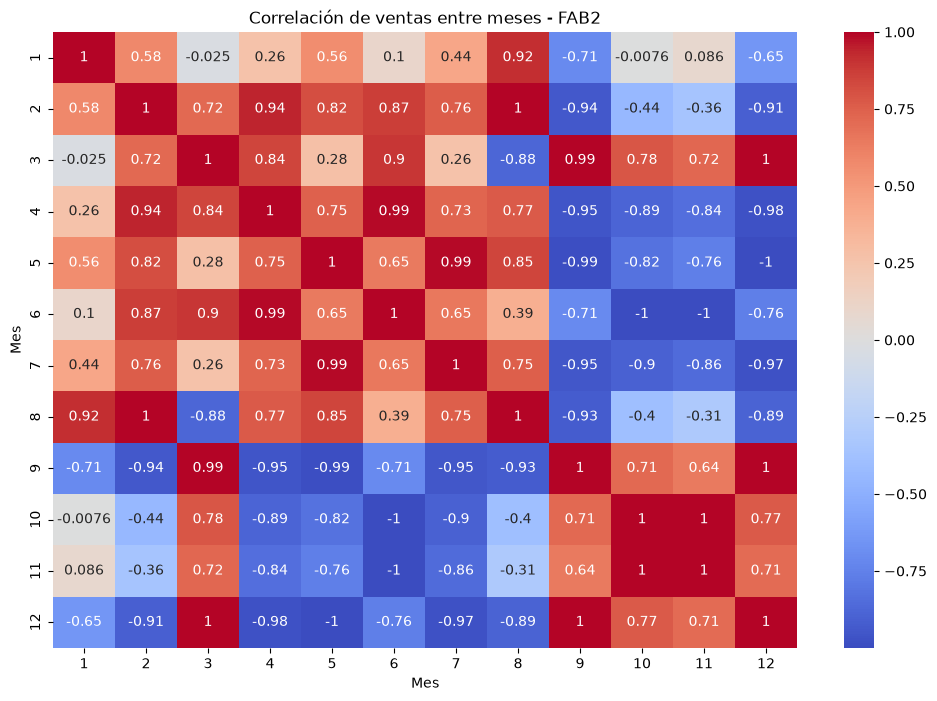

In [139]:
monthly_sales = (
    df_fab2
    .groupby(["AÑO1", "MES"])["VENTA_VALOR"]
    .sum()
    .unstack()
)

correlation_months = monthly_sales.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_months,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlación de ventas entre meses - FAB2")
plt.xlabel("Mes")
plt.ylabel("Mes")

plt.show()

La correlación entre litros y precio es de $-0.50$, lo que indica una relación lineal negativa moderada en esta muestra de FAB2, demostrando que son inversamente proporcionales entre sí.

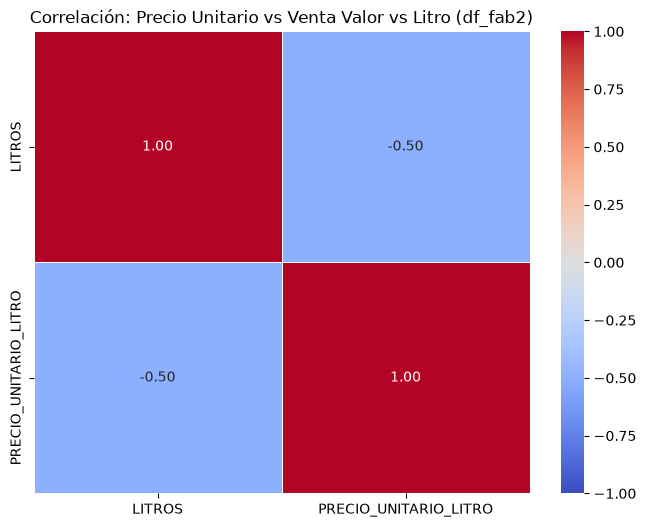

In [140]:
cols_interes = [
    "LITROS",
    "PRECIO_UNITARIO_LITRO",
]

corr_precio_valor = df_fab2[cols_interes].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_precio_valor,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Correlación: Precio Unitario vs Venta Valor vs Litro (df_fab2)")
plt.show()

## Análisis de la información

La recaudaciónde los productos se mantienen en un rango estable a lo largo del periodo del dataset, aunque se puede presenciar una caida considerable en la venta de casi todos los productos en los últimos periodos.

VENTA_VALOR
ID                  FECHAM                 
  100  70+30        2022-01-01       271.00
 100 Low C Arb      2023-11-01    402512.89
                    2023-12-01    623084.68
                    2024-01-01    679620.91
                    2024-02-01    845147.81
...                                     ...
12/1L  100 Proteina 2025-03-01   2121049.63
                    2025-04-01   2183565.36
                    2025-05-01   2667274.07
                    2025-06-01   1678837.94
                    2025-07-01   2934530.31

[207 rows x 1 columns]

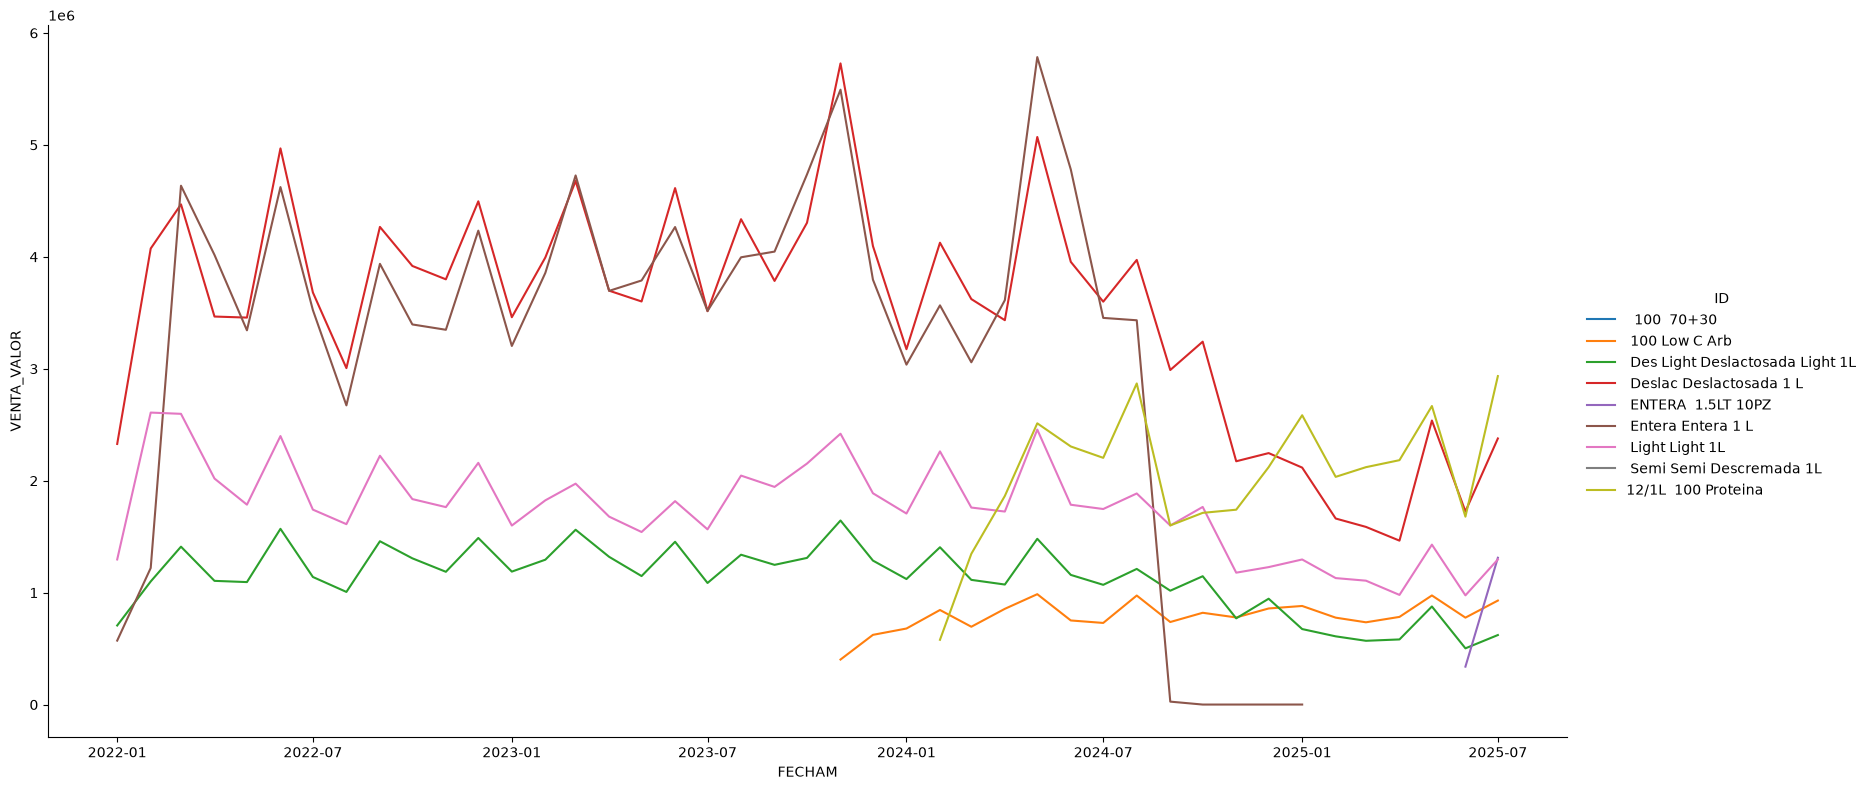

In [141]:
df_fab2_productos = df_fab2.groupby(["ID", "FECHAM"]).agg({
 	"VENTA_VALOR": "sum"
})

display(df_fab2_productos)

sns.relplot(
  data=df_fab2_productos,
  kind='line',
	x="FECHAM",
	y="VENTA_VALOR",
	hue="ID",
	height=8,
	aspect=2
  )

# Modelo exploratorio inicial: elasticidad con los últimos 12 meses

Este modelo de 12 observaciones es sólo una exploración inicial y no se utiliza para comparar el efecto de agregar controles. La comparación válida se presenta más adelante con el modelo simple y el extendido estimados sobre los mismos 43 meses.

La fórmula es:
$$\ln(Litros_t)=b_0+b_1\ln(Precio_t)+\epsilon_t$$

Donde $b_1$ se interpreta como elasticidad porcentual. El resultado exploratorio fue aproximadamente $b_1=-6.57$, con $R^2=0.708$, pero su intervalo de confianza es amplio por el tamaño muestral reducido.

Igual podemos ver que nuestro resultado es estadísticamente significativo debido a que su t-statistics, el cual mide cuántos errores estandar separan el coeficiente estimado de la hipótesis nula ($b_1 = 0$), tiene una magnitud superior a 2 y un pvalue inferior a 0.05

Las limitaciones son importantes: la tendencia y la estacionalidad quedan en el residual; el precio unitario es $\sum Valor/\sum Litros$ y puede estar relacionado con promociones y decisiones de volumen; y $R^2$ mide la proporción de variación explicada dentro de la muestra, no la calidad garantizada de las predicciones futuras. Por eso el resultado de 12 meses no debe presentarse como evidencia causal ni compararse directamente con el modelo de 43 meses.

In [142]:
fecha_max = df_fab2["FECHAM"].max()
fecha_inicio = fecha_max - pd.DateOffset(months=12)

df_last12 = df_fab2[
    (df_fab2["FECHAM"] > fecha_inicio) &
    (df_fab2["FECHAM"] <= fecha_max)
].copy()

# Producto que más vendió
top_product_sales = (
    df_last12
    .groupby("ID")["VENTA_VALOR"]
    .sum()
    .sort_values(ascending=False)
)

top_id = top_product_sales.index[0]

# Producto que más vendió
top_liters = (
    df_last12
    .groupby("ID")["LITROS"]
    .sum()
    .sort_values(ascending=False)
)

top_id = top_product_sales.index[0]
top_liters_id = top_liters.index[0]

print("Producto que genero mayor ingreso:", top_id)
print("Valor de ventas:", top_product_sales.iloc[0])
print("Producto con mayor cantidad de litros vendidos:", top_liters_id)
print("Litros vendidos:", top_liters.iloc[0])

Producto que genero mayor ingreso:  Deslac Deslactosada 1 L
Valor de ventas: 28096797.87
Producto con mayor cantidad de litros vendidos:  Deslac Deslactosada 1 L
Litros vendidos: 1274808


In [143]:
df_top = df_last12[
    df_last12["ID"] == top_id
].copy()

df_monthly = (
    df_top
    .groupby(["AÑO1", "MES"])
    .agg({
        "LITROS": "sum",
        "VENTA_VALOR": "sum"
    })
    .reset_index()
)

df_monthly["PRECIO_UNITARIO_LITRO"] = (
    df_monthly["VENTA_VALOR"] / df_monthly["LITROS"]
)

df_model = df_monthly[
    (df_monthly["LITROS"] > 0) &
    (df_monthly["PRECIO_UNITARIO_LITRO"] > 0)
].copy()

df_model["log_sales"] = np.log(df_model["LITROS"])
df_model["log_price"] = np.log(df_model["PRECIO_UNITARIO_LITRO"])

X = sm.add_constant(df_model["log_price"])
y = df_model["log_sales"]

model = sm.OLS(y, X).fit()

print(model.summary())
r2_ajustada = model.rsquared_adj
print(f"R^2 Ajustada: {r2_ajustada}")

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     24.21
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           0.000605
Time:                        17:52:05   Log-Likelihood:                 3.7669
No. Observations:                  12   AIC:                            -3.534
Df Residuals:                      10   BIC:                            -2.564
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.9028      4.143      7.700      0.0

Posteriormente tenemos la tabla del análisis descriptivo de las ventas. 
En este podemos ver por la diferencia en media y mediana de 100 mil y 80 mil, que de la cantidad de meses ha habido unos cuantos meses donde la venta ha sido mayor a lo regular, subiendo de esta manera el promedio sin afetar la mediana. Esto igual se puede entender en la discrepancia del último cuartil y el máximo con una diferencia de casi el doble. 

En cuanto al precio de venta, este tiene una distribución más cercana a la normal, con la media y la mediana teniendo menos de 1 peso de diferencia. Y sin una diferencia muy grande entre cuartiles. 

In [144]:
# Testing regression model
descriptive_stats = df_fab2[
    ["LITROS", "VENTA_VALOR", "PRECIO_UNITARIO_LITRO"]
].describe().T

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
LITROS,207.0,1.112703e+05,7.562835e+04,12.000000,5.430600e+04,8.714400e+04,1.752660e+05,3.064440e+05
VENTA_VALOR,207.0,2.172768e+06,1.336538e+06,271.000000,1.125890e+06,1.760295e+06,3.414681e+06,5.784391e+06
PRECIO_UNITARIO_LITRO,207.0,2.060603e+01,3.221277e+00,12.283787,1.808951e+01,1.967737e+01,2.263321e+01,2.874625e+01


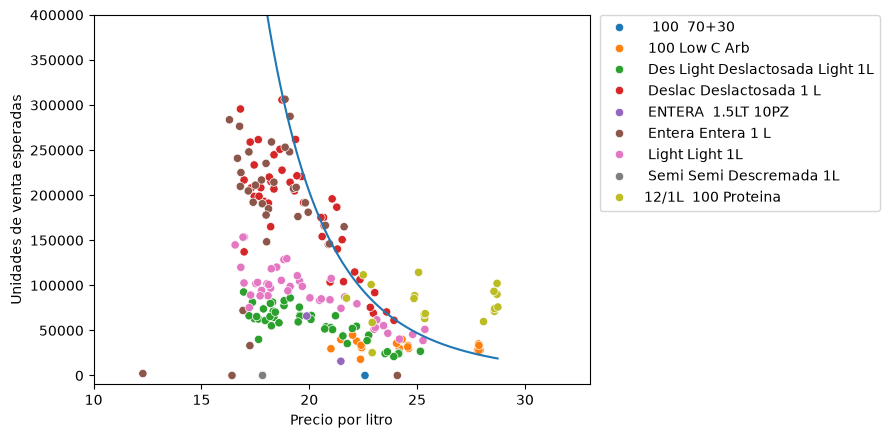

In [151]:
minimo, maximo = df_fab2["PRECIO_UNITARIO_LITRO"].min(), df_fab2["PRECIO_UNITARIO_LITRO"].max()
prices = np.arange(minimo, maximo, 0.05)
log_liters = 31.9028 + -6.5685 * np.log(prices)
liters = np.exp(log_liters)

sns.scatterplot(
	data=df_fab2,
	x="PRECIO_UNITARIO_LITRO",
 	y="LITROS",
  hue="ID"
)

sns.lineplot(x=prices, y=liters)

plt.ylim(top=400_000, bottom=-10_000)
plt.xlim(right=33, left=10)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.xlabel("Precio por litro")
plt.ylabel("Unidades de venta esperadas")
plt.show()

In [145]:
df_model["predicted_log_liters"] = model.predict(X)
df_model["error"] = np.abs(np.log(df_model["LITROS"]) - df_model["predicted_log_liters"])

display(df_model)

max_error = df_model["error"].max()
mean_error = df_model["error"].mean()
min_error = df_model["error"].min()

print("Max error", max_error)
print("Mean error", mean_error)
print("Min error", min_error)

,AÑO1,MES,LITROS,VENTA_VALOR,PRECIO_UNITARIO_LITRO,log_sales,log_price,predicted_log_liters,error
0,2024,8,186708,3972513.88,21.276613,12.137301,3.057608,11.818831,0.318470
1,2024,9,140280,2989004.06,21.307414,11.851396,3.059055,11.809329,0.042066
2,2024,10,150624,3242167.33,21.524905,11.922542,3.069211,11.742622,0.179920
3,2024,11,103680,2173795.16,20.966389,11.549065,3.042921,11.915309,0.366245
4,2024,12,104064,2246739.21,21.589975,11.552761,3.072229,11.722796,0.170034
5,2025,1,91908,2117201.82,23.036099,11.428543,3.137063,11.296936,0.131608
6,2025,2,70476,1662334.89,23.587248,11.163028,3.160706,11.141631,0.021396
7,2025,3,69108,1587463.01,22.970756,11.143426,3.134222,11.315594,0.172168
8,2025,4,61212,1464664.75,23.927739,11.022099,3.175038,11.047490,0.025392
9,2025,5,114792,2537702.13,22.106960,11.650877,3.095892,11.567362,0.083515


Max error 0.36624460145990945
Mean error 0.14274718713620219
Min error 0.02139601546770109


## Modelo con variables de temporalidad y tendencia de crecimiento

Para mejorar el modelo anterior se añadieron variables relacionadas con la temporalidad y la tendencia de crecimiento de las ventas. El modelo se estimó utilizando los 43 meses disponibles, manteniendo la misma muestra para poder comparar los resultados con el modelo simple.

Además de ln(PRECIO), se agregó una variable de tendencia (TREND) y variables dummy para los meses, tomando enero como mes de referencia. También se incorporó ln(N_SEMANAS) para controlar la diferencia en el número de semanas que tiene cada mes, ya que algunos meses cuentan con 5 semanas y otros con 4. De esta forma, no se atribuye al precio o a la estacionalidad una diferencia en volumen que simplemente se debe a que el mes tuvo una semana adicional.

ecuación del modelo es:

$$
\ln(L_t) =
b_0 +
b_1\ln(P_t) +
b_2 TREND_t +
\sum_{m=2}^{12}b_m MES
$$

El modelo presenta un estadístico de Durbin-Watson de 1.297. Al estar por debajo del rango ideal (1.5 – 2.5), esto señala la presencia de autocorrelación positiva moderada en los residuos, que indica que hay aún relación en los errores que el modelo actual no logra explicar

In [156]:
df_top = df_fab2[df_fab2["ID"] == top_id].copy()

# 2. Agrupar por AÑO y MES
df_monthly = (
    df_top.groupby(["AÑO1", "MES"])
    .agg({"LITROS": "sum", "PRECIO_UNITARIO_LITRO": "mean"})
    .reset_index()
)

# 3. Ordenar cronológicamente
df_monthly = df_monthly.sort_values(["AÑO1", "MES"]).reset_index(drop=True)

# 4. Filtrar ceros antes de aplicar logaritmos
df_model = df_monthly[
    (df_monthly["LITROS"] > 0) & (df_monthly["PRECIO_UNITARIO_LITRO"] > 0)
].copy()

# 5. Crear logaritmos y tendencia
df_model["log_sales"] = np.log(df_model["LITROS"])
df_model["log_price"] = np.log(df_model["PRECIO_UNITARIO_LITRO"])
df_model["TREND"] = np.arange(1, len(df_model) + 1)

# 6. Crear Dummies omitiendo el primer mes (drop_first=True evita multicolinealidad)
df_model = pd.get_dummies(df_model, columns=["MES"], drop_first=True)

# 7. Definir X e y
mes_cols = [col for col in df_model.columns if col.startswith("MES_")]
X = df_model[["log_price", "TREND"] + mes_cols].astype(float)
X = sm.add_constant(X)
y = df_model["log_sales"]

# 8. Ajustar modelo OLS
model_extended = sm.OLS(y, X).fit()

print(model_extended.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                     6.415
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           1.63e-05
Time:                        19:09:58   Log-Likelihood:                 7.2822
No. Observations:                  43   AIC:                             13.44
Df Residuals:                      29   BIC:                             38.09
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.7416      3.817      7.268      0.0

In [157]:
print(f"Elasticidad: {model_extended.params['log_price']:.4f}")
print(f"Tendencia: {model_extended.params['TREND']:.4f}")
print(f"R²: {model_extended.rsquared:.4f}")
print(f"R² ajustada: {model_extended.rsquared_adj:.4f}")

Elasticidad: -5.4685
Tendencia: 0.0187
R²: 0.7420
R² ajustada: 0.6263


## Comparación e interpretación de los modelos

Para responder si cambió la elasticidad, ambos modelos deben usar los mismos 43 meses. El modelo simple comparable, con solo $\ln(P)$, estima una elasticidad de $-6.5685$. Al agregar tendencia y estacionalidad, el coeficiente de precio es $-5.4685$. Por tanto, la elasticidad **aumentó numéricamente**  y disminuyó en magnitud absoluta, dando menor sensibilidad al precio.

Manteniendo constantes la tendencia y el mes, un incremento de 1% en el precio se asocia con una disminución aproximada de 5.46% en los litros vendidos, manteniendo constantes las demás variables del modelo. Debido a que |$b_1$| > 1, la demanda es elástica respecto al precio. La tendencia es positiva ($0.0184$ por mes), pero su evidencia individual es marginal al 5%. El precio sí es estadísticamente significativo ($t=-4.050$, $p<0.001$; IC 95% aproximadamente $[-7.85,-3.19]$).

Debido a que el intervalo de confianza no contiene al 0, entonces tenemos evidencia estadística que la elasticidad es diferente a 0 con el nivel de confianza superior al 95%.

El modelo extendido explica el 74.2% de la variación muestral de $\ln(LITROS)$. Este valor no mide que tan bien funcionará para predecir datos futuros. El Durbin-Watson de 1.297 lo que sugiere la presencia de autocorrelación positiva moderada en los residuos. Esto indica que todavía existe cierta estructura temporal que el modelo no logra explicar completamente.

In [ ]:
df_model["predicted_log_liters"] = model.predict(X)
df_model["error"] = np.abs(np.log(df_model["LITROS"]) - df_model["predicted_log_liters"])

display(df_model)

max_error = df_model["error"].max()
mean_error = df_model["error"].mean()
min_error = df_model["error"].min()

print("Max error", max_error)
print("Mean error", mean_error)
print("Min error", min_error)

,FECHAM,AÑO1,MES,LITROS,VENTA_VALOR,N_SEMANAS,PRECIO_UNITARIO_LITRO,log_sales,log_price,log_weeks,TREND,predicted_log_liters,error
0,2022-01-01,2022,1,137136,2328456.02,4,16.979174,11.828728,2.831988,1.386294,1,11.818831,0.009897
1,2022-02-01,2022,2,233556,4074388.11,4,17.445016,12.361177,2.859054,1.386294,2,11.809329,0.551848
2,2022-03-01,2022,3,258912,4468837.57,5,17.260064,12.464244,2.848395,1.609438,3,11.742622,0.721621
3,2022-04-01,2022,4,198684,3466617.89,4,17.447897,12.199471,2.859219,1.386294,4,11.915309,0.284162
4,2022-05-01,2022,5,193200,3457344.17,4,17.895156,12.171481,2.884530,1.386294,5,11.722796,0.448686
5,2022-06-01,2022,6,295620,4968837.71,5,16.808192,12.596830,2.821866,1.609438,6,11.296936,1.299894
6,2022-07-01,2022,7,216864,3681598.32,4,16.976531,12.287026,2.831832,1.386294,7,11.141631,1.145394
7,2022-08-01,2022,8,165060,3005916.62,4,18.211054,12.014064,2.902029,1.386294,8,11.315594,0.698470
8,2022-09-01,2022,9,227760,4267421.69,5,18.736484,12.336048,2.930473,1.609438,9,11.047490,1.288557
9,2022-10-01,2022,10,215052,3918524.95,4,18.221290,12.278635,2.902591,1.386294,10,11.567362,0.711273


Max error 1.2998944055705142
Mean error 0.7464342014426452
Min error 0.009897021959679009


## Idea de mejora

Una estrategia diferente para predecir las ventas de los siguientes 24 meses puede ser el método de **Monte Carlo**. 
*(Pensé en este método porque se planea utilizar en mi servicio becario)*

Se utiliza para simulaciones aleatorias donde se crean múltiples predicciones con diferentes valores y variables para generar rangos de posibles escenarios. Con este modelo no se tiene solo una predicción de cómo van a ser las ventas en los siguientes meses, pero también la probabilidad y cómo sería el peor caso posible, la probabilidad de cumplir metas, el caso más probable, etc. 

Este sería facil de aplicar con la información que tenemos hasta el momento pues ya tenemos el rango de predicciones que puede utilizar el modelo, con este podemos simular varios escenarios y analizar los resultados obtenidos de estos para determinar qué es lo más probable que suceda. 

Campagna, G. (2026, agosto 5). Método de Monte Carlo: ué es, ejemplos y aplicacioes. pipedrive. [Método de Monte Carlo: ué es, ejemplos y aplicacioes](https://www.pipedrive.com/es/blog/metodo-monte-carlo)